In [1]:
import scipy.stats as st
import numpy as np

T = [0.02, 0.08, 0.25, 0.50]
K_S = [0.8, 0.9, 1.0, 1.1]
S_0 = 100
K = [S_0*k_s for k_s in K_S]
SIGMA = 0.2
LAMBDA = 0.2
GAMMA = -0.08
R = 0.04

def factorial(n):
    if n > 1:
        return n*factorial(n-1)
    else:
        return 1

    
#------------------- definition of d1 and d2 for BS formula --------------------------
def d1(k, tau, s = S_0,r = R, sigma = SIGMA, q = 0):
    return (np.log(s/k) + (r - q + 0.5*sigma*sigma)*tau) / (sigma*np.sqrt(tau))

def d2(k, tau,s = S_0, r = R, sigma = SIGMA, q = 0):
    return d1(k, tau, s, r , sigma, q) - sigma * np.sqrt(tau)
#------------------- Definition of BS model call option -----------------------------
def BS_call(k, tau, s = S_0, r = R, sigma = SIGMA,  q = 0):
    return s * np.exp(-q * tau) * st.norm.cdf(d1(k,tau, s, r, sigma, q)) - k * np.exp(-r * tau)*st.norm.cdf(d2(k, tau, s, r, sigma, q))

#--------------------------- Definition of Poisson pdf -----------------------------
def Poisson(n, t,  l = LAMBDA):
    return  np.exp(-l*t)*(l * t)**n / factorial(n)

#----------------- definition of function to cover 1- 10e-14 mass ------------------
def find_n(t, l = LAMBDA):
    x = 0
    n = 0
    while(x < 1- 10e-14):
        x += Poisson(n, t, l)
        n += 1
    return n
#-------------- Call price with jump log normal stock returns ----------------------
def BS_jump(k, tau, s = S_0, r = R, sigma = SIGMA, g = GAMMA, l = LAMBDA):
    c = 0
    j_max = find_n(tau, l)
    for j in range(j_max):
        c += Poisson(j, tau) * BS_call(k, tau, s*(1+g)**j, r, sigma, l*g)
        
    return c

#---------------------------------- Call price omputation --------------------------
for k in K:
    for tau in T:
        print(f"K = {k:.1f}, T = {tau:.2f}, BS price = {BS_call(k, tau):.4f}, BS price with jump = {BS_jump(k, tau):.4f}")


K = 80.0, T = 0.02, BS price = 20.0640, BS price with jump = 20.0640
K = 80.0, T = 0.08, BS price = 20.2556, BS price with jump = 20.2558
K = 80.0, T = 0.25, BS price = 20.8257, BS price with jump = 20.8335
K = 80.0, T = 0.50, BS price = 21.8022, BS price with jump = 21.8287
K = 90.0, T = 0.02, BS price = 10.0720, BS price with jump = 10.0733
K = 90.0, T = 0.08, BS price = 10.3439, BS price with jump = 10.3573
K = 90.0, T = 0.25, BS price = 11.4770, BS price with jump = 11.5192
K = 90.0, T = 0.50, BS price = 13.1476, BS price with jump = 13.2162
K = 100.0, T = 0.02, BS price = 1.1683, BS price with jump = 1.1802
K = 100.0, T = 0.08, BS price = 2.4162, BS price with jump = 2.4489
K = 100.0, T = 0.25, BS price = 4.4852, BS price with jump = 4.5488
K = 100.0, T = 0.50, BS price = 6.6271, BS price with jump = 6.7183
K = 110.0, T = 0.02, BS price = 0.0003, BS price with jump = 0.0003
K = 110.0, T = 0.08, BS price = 0.1287, BS price with jump = 0.1338
K = 110.0, T = 0.25, BS price = 1.1404, 

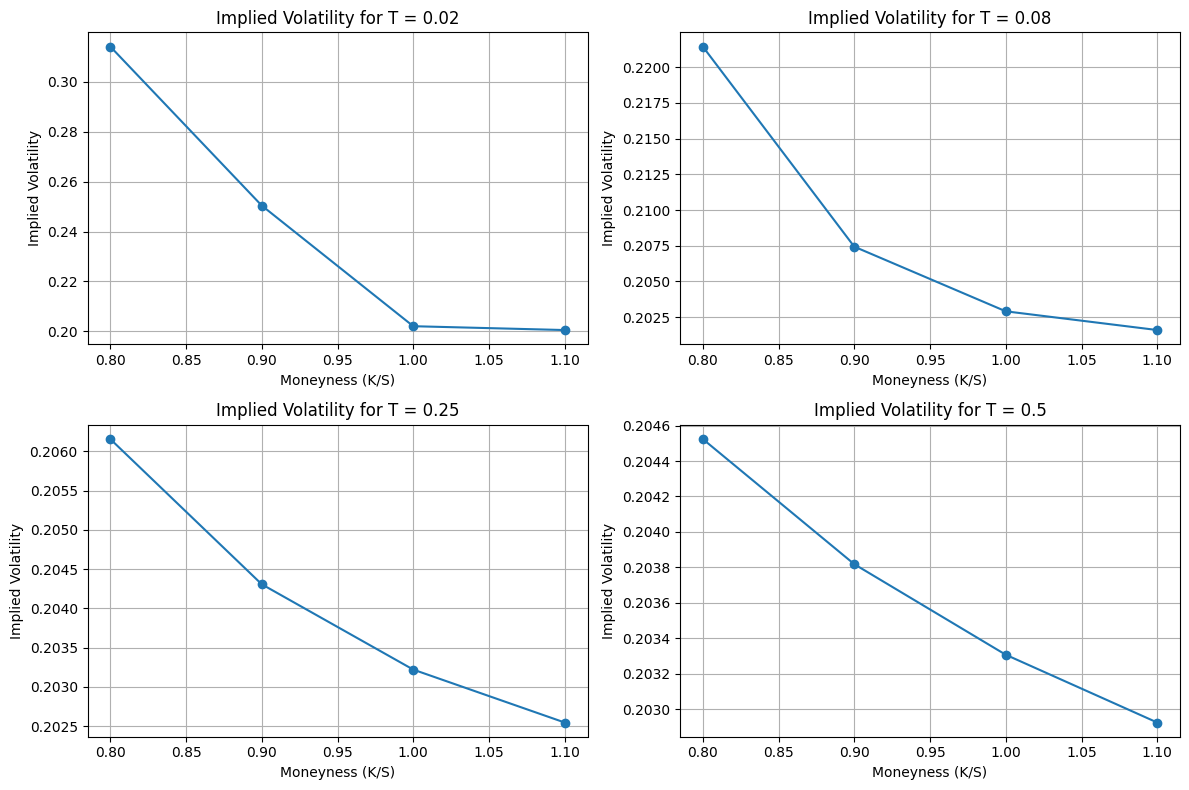

In [3]:
from scipy import optimize
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()  

for idx, tau in enumerate(T):
    k_over_s = []
    iv = []
    for k in K:
        #objective function to set = 0
        def f(iv):
            return BS_call(k, tau, sigma=iv) - BS_jump(k, tau)
        k_over_s.append(k/S_0)
        iv.append(optimize.brentq(f, 1e-14, 1))
    axs[idx].plot(k_over_s, iv, marker='o')
    axs[idx].set_xlabel("Moneyness (K/S)")
    axs[idx].set_ylabel("Implied Volatility")
    axs[idx].set_title(f"Implied Volatility for T = {tau}")
    axs[idx].grid(True)

plt.tight_layout()
plt.show()